#Task 2: Custom Byte-Pair Encoding (BPE) Tokenizer & Autoregressive Causal LM

###Objective

To understand subword tokenization and autoregressive sequence generation by building a language model training loop from the ground up.

###Technologies / Tools Used
PyTorch,
Python,
NumPy,
Google Colab

#Step 1: Import Required Libraries

Import PyTorch, Python utilities, and NumPy required for the implementation.

PyTorch is used for tensor operations, while Python and NumPy support the tokenizer implementation and data processing.

In [7]:
# Import required libraries
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from collections import Counter

# Set random seeds
torch.manual_seed(42)
np.random.seed(42)

#Step 2: Prepare the Text Corpus

Create a small custom text corpus for training the BPE tokenizer.

A corpus is a collection of text used to build and train the tokenizer.

In [8]:
# Create a small custom text corpus
text = "hello world hello machine learning world"

print("Text Corpus:")
print(text)

Text Corpus:
hello world hello machine learning world


#Step 3: Create Initial Tokens

Convert the text into individual characters or basic tokens.

These initial tokens form the starting vocabulary for the BPE algorithm.

In [9]:
# Convert text into individual characters
tokens = list(text)

# Create the initial vocabulary
vocab = sorted(set(tokens))

print("Initial Vocabulary:")
print(vocab)

Initial Vocabulary:
[' ', 'a', 'c', 'd', 'e', 'g', 'h', 'i', 'l', 'm', 'n', 'o', 'r', 'w']


#Step 4: Count Token Pairs

Count how frequently adjacent token pairs occur in the corpus.

The most frequent pair will be selected for merging.

In [10]:
# Count adjacent token pairs
pairs = Counter(
    zip(tokens[:-1], tokens[1:])
)

# Display the most frequent pairs
print("Most Frequent Token Pairs:")
print(pairs.most_common(5))

Most Frequent Token Pairs:
[(('h', 'e'), 2), (('e', 'l'), 2), (('l', 'l'), 2), (('l', 'o'), 2), (('o', ' '), 2)]


#Step 5: Merge Frequent Token Pairs

Merge the most frequent pair into a new token and update the vocabulary.

Byte-Pair Encoding (BPE) is a subword tokenization method that repeatedly merges frequent token pairs.

In [11]:
# Perform BPE merging
for i in range(5):

    # Count token pairs
    pairs = Counter(
        zip(tokens[:-1], tokens[1:])
    )

    # Stop if no pairs are available
    if not pairs:
        break

    # Find the most frequent pair
    best_pair = pairs.most_common(1)[0][0]

    # Create a new merged token
    new_token = best_pair[0] + best_pair[1]

    # Replace the pair with the new token
    new_tokens = []
    j = 0

    while j < len(tokens):

        if (
            j < len(tokens) - 1
            and (tokens[j], tokens[j + 1]) == best_pair
        ):
            new_tokens.append(new_token)
            j += 2
        else:
            new_tokens.append(tokens[j])
            j += 1

    tokens = new_tokens

    # Add the new token to the vocabulary
    if new_token not in vocab:
        vocab.append(new_token)

print("Final Vocabulary:")
print(vocab)

print("\nFinal Tokens:")
print(tokens)

Final Vocabulary:
[' ', 'a', 'c', 'd', 'e', 'g', 'h', 'i', 'l', 'm', 'n', 'o', 'r', 'w', 'he', 'hel', 'hell', 'hello', 'hello ']

Final Tokens:
['hello ', 'w', 'o', 'r', 'l', 'd', ' ', 'hello ', 'm', 'a', 'c', 'h', 'i', 'n', 'e', ' ', 'l', 'e', 'a', 'r', 'n', 'i', 'n', 'g', ' ', 'w', 'o', 'r', 'l', 'd']


#Step 6: Create Token-to-ID Mapping

Convert each token into a numerical ID.

A token ID is a number representing a token so that it can be processed by the language model.

In [12]:
# Create token-to-ID mapping
token_to_id = {
    token: i
    for i, token in enumerate(vocab)
}

# Convert tokens into IDs
token_ids = [
    token_to_id[token]
    for token in tokens
]

print("Token to ID Mapping:")
print(token_to_id)

print("\nToken IDs:")
print(token_ids)

Token to ID Mapping:
{' ': 0, 'a': 1, 'c': 2, 'd': 3, 'e': 4, 'g': 5, 'h': 6, 'i': 7, 'l': 8, 'm': 9, 'n': 10, 'o': 11, 'r': 12, 'w': 13, 'he': 14, 'hel': 15, 'hell': 16, 'hello': 17, 'hello ': 18}

Token IDs:
[18, 13, 11, 12, 8, 3, 0, 18, 9, 1, 2, 6, 7, 10, 4, 0, 8, 4, 1, 12, 10, 7, 10, 5, 0, 13, 11, 12, 8, 3]


#Step 7: Prepare Input and Target Sequences

Create input and target sequences for next-token prediction.

The input contains the current tokens, while the target contains the next tokens that the model should predict.

#Step 8: Create the Causal Mask

Create a lower-triangular matrix to prevent the model from looking at future tokens.

A causal mask ensures that each token can only see itself and the tokens before it.

In [13]:
# Define sequence length
sequence_length = 6

# Create a lower triangular causal mask
causal_mask = torch.tril(
    torch.ones(
        sequence_length,
        sequence_length
    )
)

print("Causal Mask:")
print(causal_mask)

Causal Mask:
tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])


#Step 9: Create a Simple Causal Language Model

Create a small neural network that predicts the next token.

An autoregressive language model predicts the next token based on previously available tokens.

#Step 10: Train the Language Model

Train the model to predict the next token in the sequence.

The model learns from the input sequence and its corresponding next-token targets.

In [14]:
# Convert token IDs into a PyTorch tensor
data = torch.tensor(
    token_ids,
    dtype=torch.long
)

# Create input and target sequences
X = data[:-1].unsqueeze(0)
Y = data[1:].unsqueeze(0)

# Vocabulary size
vocab_size = len(vocab)

# Create a simple language model
model = nn.Sequential(
    nn.Embedding(vocab_size, 16),
    nn.Linear(16, vocab_size)
)

# Define loss function and optimizer
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01
)

losses = []

# Train the model
for epoch in range(200):

    # Forward pass
    predictions = model(X)

    # Calculate loss
    loss = loss_function(
        predictions.reshape(-1, vocab_size),
        Y.reshape(-1)
    )

    # Clear old gradients
    optimizer.zero_grad()

    # Calculate gradients
    loss.backward()

    # Update model parameters
    optimizer.step()

    losses.append(loss.item())

    # Display progress
    if (epoch + 1) % 50 == 0:
        print(
            "Epoch:",
            epoch + 1,
            "Loss:",
            round(loss.item(), 4)
        )

Epoch: 50 Loss: 0.6245
Epoch: 100 Loss: 0.5173
Epoch: 150 Loss: 0.5094
Epoch: 200 Loss: 0.5066


#Step 11: Generate Text

Use the trained model to predict the next token.

The model generates tokens one at a time, which demonstrates autoregressive generation.

In [15]:
# Start with the first token
generated = [token_ids[0]]

# Generate 10 additional tokens
for _ in range(10):

    # Convert current tokens to tensor
    input_tensor = torch.tensor(
        [generated],
        dtype=torch.long
    )

    # Get model predictions
    predictions = model(input_tensor)

    # Get the prediction for the last token
    next_token = predictions[0, -1].argmax().item()

    # Add the predicted token
    generated.append(next_token)

# Convert IDs back to tokens
id_to_token = {
    value: key
    for key, value in token_to_id.items()
}

generated_text = [
    id_to_token[i]
    for i in generated
]

print("Generated Tokens:")
print(generated_text)

print("\nGenerated Text:")
print("".join(generated_text))

Generated Tokens:
['hello ', 'w', 'o', 'r', 'l', 'd', ' ', 'hello ', 'w', 'o', 'r']

Generated Text:
hello world hello wor


#Step 12: Visualize the Results

Visualize the causal mask and training loss.

The causal mask shows which positions are allowed to attend to each other, while the loss graph shows the training progress.

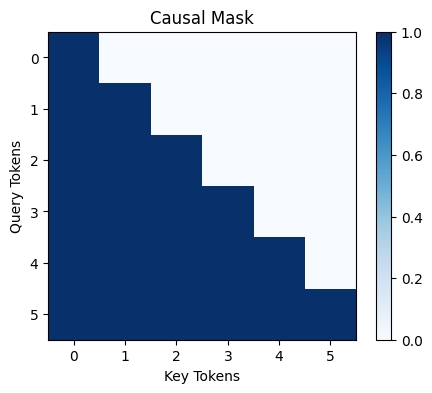

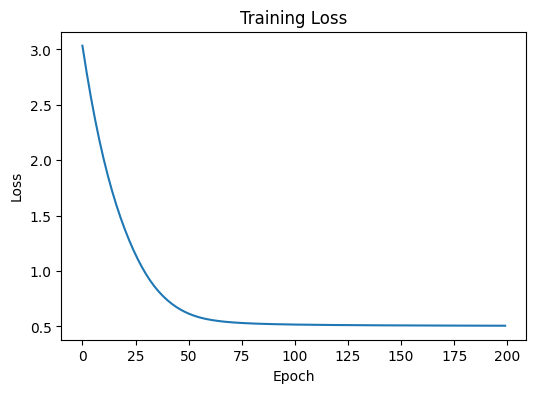

In [16]:
# Create two separate visualizations

# 1. Causal mask
plt.figure(figsize=(5, 4))

plt.imshow(
    causal_mask.numpy(),
    cmap="Blues"
)

plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")
plt.title("Causal Mask")
plt.colorbar()

plt.show()


# 2. Training loss
plt.figure(figsize=(6, 4))

plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.show()

#Conclusion

The custom BPE tokenizer and autoregressive causal language model were implemented using Python, PyTorch, and NumPy. The implementation includes frequent token-pair merging, token-to-ID conversion, causal masking, next-token prediction, model training, text generation, and visualization.